In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

results_dir = Path(".")  # notebook is in results/
df = pd.read_csv(results_dir / "lrt_nb_vs_zinb_results.tsv", sep="\t")

In [2]:
# Parse comparison column into dataset and model_type
df[["dataset", "model_type"]] = df["comparison"].str.split(" / ", expand=True)

# Dataset display order and labels
dataset_order = [
    "seelig_cm", "seelig_cm_moib",
    "shendure_obs", "shendure_cm",
    "cohen_obs", "cohen_cm", "cohen_obsingle",
    "takeshi_obs", "takeshi_cm",
]
dataset_labels = {
    "seelig_cm":       "Seelig (CM)",
    "seelig_cm_moib":  "Seelig (MOIB)",
    "shendure_obs":    "Shendure (obs)",
    "shendure_cm":     "Shendure (CM)",
    "cohen_obs":       "Cohen (obs)",
    "cohen_cm":        "Cohen (CM)",
    "cohen_obsingle":  "Cohen (obsingle)",
    "takeshi_obs":     "Takeshi (obs)",
    "takeshi_cm":      "Takeshi (CM)",
}

by_cre = df[df["model_type"] == "by_cre"]
by_ct  = df[df["model_type"] == "by_cell_type"]

print("by_cre n per dataset:", by_cre.groupby("dataset").size().to_dict())
print("by_cell_type n per dataset:", by_ct.groupby("dataset").size().to_dict())

by_cre n per dataset: {'cohen_cm': 114, 'cohen_obs': 114, 'cohen_obsingle': 114, 'seelig_cm': 1344, 'shendure_cm': 208, 'shendure_obs': 208, 'takeshi_cm': 150, 'takeshi_obs': 150}
by_cell_type n per dataset: {'cohen_cm': 4, 'cohen_obs': 4, 'cohen_obsingle': 4, 'seelig_cm': 2, 'shendure_cm': 10, 'shendure_obs': 10, 'takeshi_cm': 3, 'takeshi_obs': 3}


Saved lrt_nb_vs_zinb_delta_aic.svg


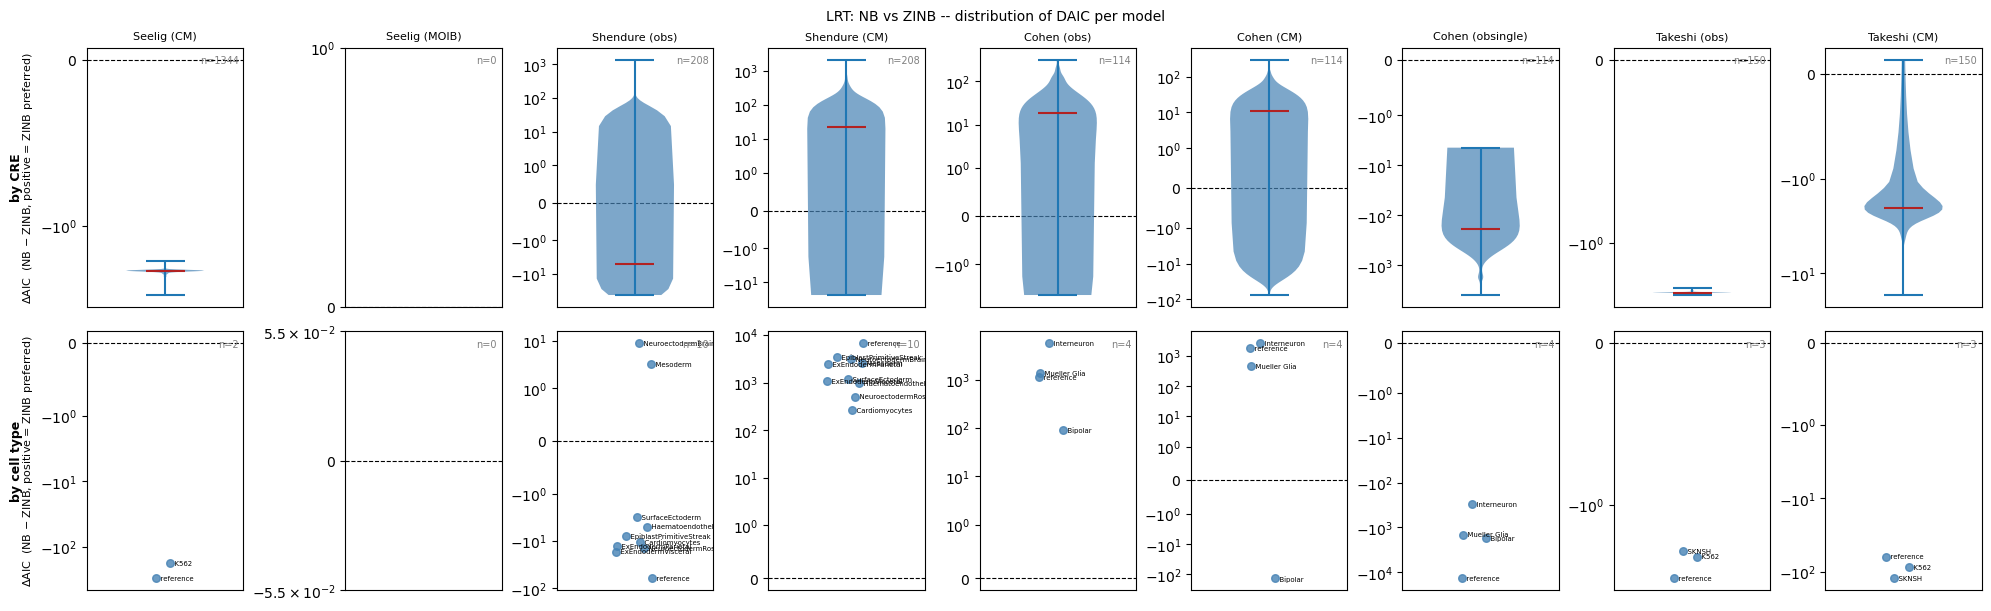

In [3]:
n_ds = len(dataset_order)

fig, axes = plt.subplots(
    2, n_ds,
    figsize=(2.2 * n_ds, 6),
    constrained_layout=True,
)

metric = "delta_aic"  # ΔAIC: positive = ZINB preferred
metric_label = r"$\Delta$AIC  (NB $-$ ZINB, positive = ZINB preferred)"

for col, ds in enumerate(dataset_order):
    # --- top row: by_cre violin ---
    ax = axes[0, col]
    sub = by_cre[by_cre["dataset"] == ds][metric].dropna()
    ax.axhline(0, color="black", lw=0.8, ls="--", zorder=0)
    if len(sub) > 1:
        parts = ax.violinplot(sub, positions=[0], showmedians=True, widths=0.6)
        parts["cmedians"].set_color("firebrick")
        for pc in parts["bodies"]:
            pc.set_facecolor("steelblue")
            pc.set_alpha(0.7)
    elif len(sub) == 1:
        ax.scatter([0], sub.values, s=40, color="steelblue", zorder=2)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_title(dataset_labels[ds], fontsize=8)
    ax.set_xticks([])
    ax.set_xlim(-0.6, 0.6)
    n = len(sub)
    ax.text(0.97, 0.97, f"n={n}", transform=ax.transAxes,
            ha="right", va="top", fontsize=7, color="gray")
    if col == 0:
        ax.set_ylabel(metric_label, fontsize=8)

    # --- bottom row: by_cell_type strip ---
    ax2 = axes[1, col]
    sub2 = by_ct[by_ct["dataset"] == ds][[metric, "model"]].dropna()
    ax2.axhline(0, color="black", lw=0.8, ls="--", zorder=0)
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(sub2))
    ax2.scatter(jitter, sub2[metric], s=30, color="steelblue", alpha=0.8, zorder=2)
    for x, (_, row) in zip(jitter, sub2.iterrows()):
        ax2.text(x, row[metric], "  " + row["model"], fontsize=5, va="center", clip_on=True)
    ax2.set_yscale("symlog", linthresh=1)
    ax2.set_xticks([])
    ax2.set_xlim(-0.6, 0.6)
    n2 = len(sub2)
    ax2.text(0.97, 0.97, f"n={n2}", transform=ax2.transAxes,
             ha="right", va="top", fontsize=7, color="gray")
    if col == 0:
        ax2.set_ylabel(metric_label, fontsize=8)

# Row labels
axes[0, 0].annotate("by CRE", xy=(0, 0.5), xytext=(-0.45, 0.5),
    xycoords="axes fraction", textcoords="axes fraction",
    fontsize=9, fontweight="bold", rotation=90, va="center", ha="center")
axes[1, 0].annotate("by cell type", xy=(0, 0.5), xytext=(-0.45, 0.5),
    xycoords="axes fraction", textcoords="axes fraction",
    fontsize=9, fontweight="bold", rotation=90, va="center", ha="center")

fig.suptitle("LRT: NB vs ZINB -- distribution of DAIC per model", fontsize=10)

out = results_dir / "lrt_nb_vs_zinb_delta_aic.svg"
fig.savefig(out, format="svg", bbox_inches="tight")
print(f"Saved {out}")
plt.show()

/tmp/ipykernel_738922/1774041528.py:21: RuntimeWarning: Mean of empty slice
  means.append(vals.mean())
/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_738922/1774041528.py:22: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sems.append(stats.sem(vals))
/tmp/ipykernel_738922/1774041528.py:21: RuntimeWarning: Mean of empty slice
  means.append(vals.mean())
/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_738922/1774041528.py:22: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sems.append(stats.sem(vals))


Saved lrt_nb_vs_zinb_barchart.svg


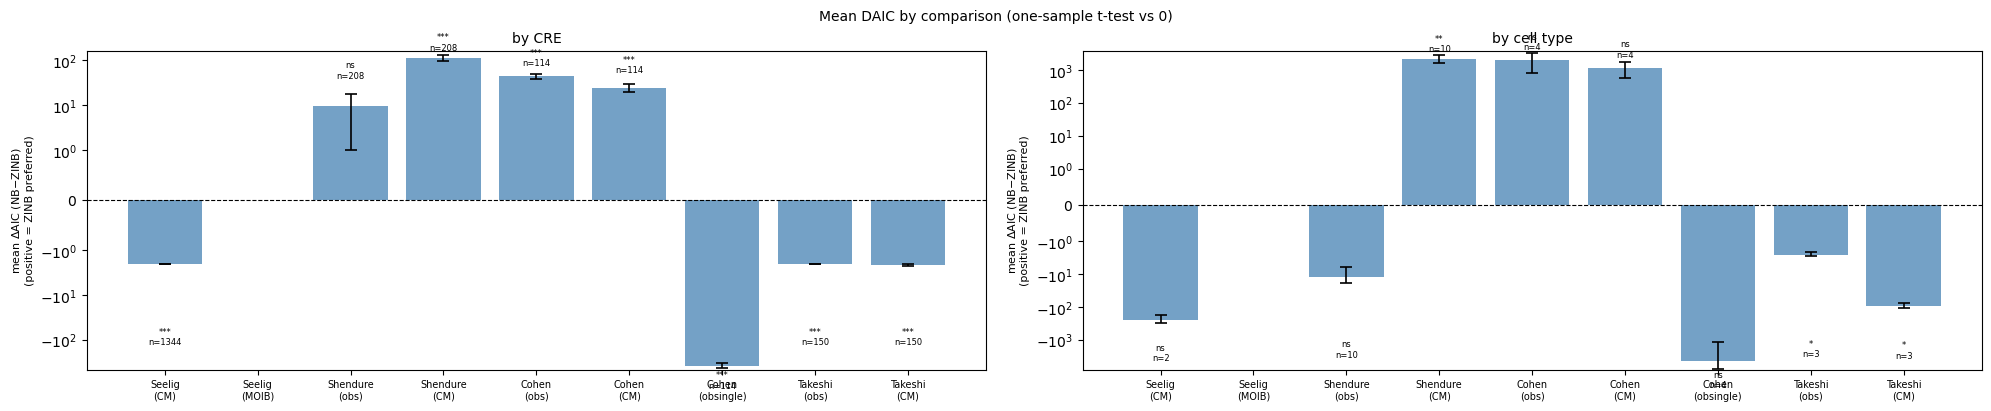

In [4]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(2.2 * n_ds, 4), constrained_layout=True)

row_labels = {"by_cre": "by CRE", "by_cell_type": "by cell type"}
bar_labels = {k: v.replace(" (", "\n(") for k, v in dataset_labels.items()}

def sig_stars(p):
    if np.isnan(p): return "n/a"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

for ax, model_type in zip(axes, ["by_cre", "by_cell_type"]):
    sub = df[df["model_type"] == model_type]

    means, sems, pvals, ns = [], [], [], []
    for ds in dataset_order:
        vals = sub[sub["dataset"] == ds][metric].dropna().values
        means.append(vals.mean())
        sems.append(stats.sem(vals))
        ns.append(len(vals))
        pvals.append(stats.ttest_1samp(vals, 0).pvalue if len(vals) > 1 else np.nan)

    x = np.arange(len(dataset_order))
    ax.bar(x, means, yerr=sems, capsize=4, color="steelblue", alpha=0.75,
           error_kw=dict(lw=1.2, capthick=1.2))
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_yscale("symlog", linthresh=1)
    ax.set_xticks(x)
    ax.set_xticklabels([bar_labels[d] for d in dataset_order], fontsize=7)
    ax.set_ylabel(r"mean $\Delta$AIC (NB$-$ZINB)" + "\n(positive = ZINB preferred)", fontsize=8)
    ax.set_title(row_labels[model_type], fontsize=10)

    ymin, ymax = ax.get_ylim()
    span = ymax - ymin
    for xi, (m, se, p, n) in enumerate(zip(means, sems, pvals, ns)):
        label = f"{sig_stars(p)}\nn={n}"
        ypos = m + se + span * 0.03 if m >= 0 else m - se - span * 0.08
        ax.text(xi, ypos, label, ha="center", va=("bottom" if m >= 0 else "top"), fontsize=6)

fig.suptitle("Mean DAIC by comparison (one-sample t-test vs 0)", fontsize=10)
out = results_dir / "lrt_nb_vs_zinb_barchart.svg"
fig.savefig(out, format="svg", bbox_inches="tight")
print(f"Saved {out}")
plt.show()